# Tarea 2: Regresión        
El objetivo de esta tarea es construir modelos de regresión supervisada para predecir la variable nota_media_2sem.

Vamos a comparar cuatro modelos:
- Lasso: regularización L1, puede llevar coeficientes a cero.
- Ridge: regularización L2, penaliza coeficientes grandes.
- ElasticNet: combina L1 y L2, útil cuando hay variables correlacionadas.
- Random Forest Regressor: modelo no lineal basado en árboles, más flexible y robusto.

No incluyo regresión lineal sin regularización como modelo base porque con el número de variables resultantes tras el one-hot encoding, puede llevar al sobreajuste. Ridge, Lasso y elasticNet añaden regularización, por lo que sé que serán mejores modelos.

## 1. Importaciones

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor

sys.path.append(os.path.abspath(".."))
from src.preprocesado import plot_hist_box, plot_residuos, plot_real_vs_pred

## 2. Carga de datos

In [22]:
df = pd.read_pickle("../data/df_limpio.pkl")

TARGET = 'nota_media_2sem'

columnas_a_eliminar = ['asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas',
                    'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas', 'asignaturas_2sem_sin_evaluacion', 'objetivo']

X = df.drop(columns=columnas_a_eliminar + [TARGET])
y = df[TARGET]

print('Dimensiones de X:', X.shape)

Dimensiones de X: (4424, 29)


### Distribución de la variable objetivo       
Antes de modelar, vamos a analizar la distribución de la variable a predecir para detectar posibles outliers o asimetrías.

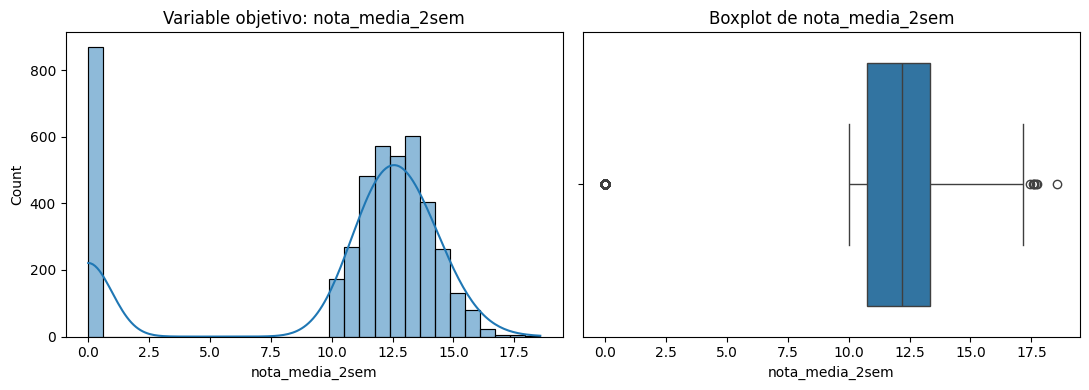

count    4424.000000
mean       10.230206
std         5.210808
min         0.000000
25%        10.750000
50%        12.200000
75%        13.333333
max        18.571429
Name: nota_media_2sem, dtype: float64


In [23]:
plot_hist_box(df, 'nota_media_2sem', titulo='Variable objetivo: nota_media_2sem')
print(y.describe())

## 3. División train y test y modelado      
Dividimos el dataset en 80% entrenamiento y 20% test con la función train_test_split. Al igual que en clasificación, el escalado y one-hot encoding lo integramos en un Pipeline para evitar data leakage en la validación cruzada.

In [24]:
#  División del conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (3539, 29)
X_test: (885, 29)


In [25]:
columnas_categoricas_bin = [
    'desplazado', 'es_mujer', 'internacional', 'asistencia_diurna',
    'necesidades_educativas_especiales', 'deudor', 'matricula_al_dia', 'becado'
]
columnas_categoricas = [
    'estado_civil', 'modo_solicitud', 'curso',
    'cualificacion_previa', 'cualificacion_madre', 'cualificacion_padre',
    'ocupacion_madre', 'ocupacion_padre'
]
columnas_numericas = [
    'edad_al_matricularse', 'orden_solicitud', 'nota_cualificacion_previa', 'nota_admision',
    'tasa_desempleo', 'tasa_inflacion', 'pib',
    'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas',
    'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas',
    'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion'
]

# ColumnTransformer: aplica transformaciones distintas según el tipo de columna
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), columnas_numericas),
                                               ('bin', 'passthrough', columnas_categoricas_bin),
                                               ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_categoricas)])
cv = KFold(n_splits=5, shuffle=True, random_state=42)
resultados_reg = [] # para hacer una comparación al final

### Función auxiliar para evaluar los modelos       

In [26]:
# Calcula MAE, RMSE y R**2 y muestra los resultados
def evaluar_modelo(nombre, y_true, y_pred, resultados):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(nombre)
    print("MAE: ", mae)
    print("RMSE: ", rmse)
    print("R2: ", r2)
    resultados.append({'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    return mae, rmse, r2

## Modelo 1: RIDGE      
Ridge añade una penalización L2 a los coeficientes, lo que reduce el sobreajuste cuando hay muchas variables. Además, el parámetro alpha controla la intensidad de la regularización: si es alto penaliza más y acerca los coeficientes a cero. Ese valor lo buscamos con GridSearch.

In [27]:
pipe_ridge = Pipeline([('prep', preprocessor),
                       ('reg', Ridge())])

# Buscamos alpha con CV
param_ridge = {'reg__alpha': [0.01, 0.1, 1, 10, 100]}

ridge = GridSearchCV(pipe_ridge, param_grid=param_ridge, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge.fit(X_train, y_train)

print("Mejor alpha Ridge: ", ridge.best_params_)
print("Mejor RMSE CV: ", ridge.best_score_)

# Predecimos
y_pred_ridge = ridge.predict(X_test)
evaluar_modelo('Ridge', y_test, y_pred_ridge, resultados_reg)

Mejor alpha Ridge:  {'reg__alpha': 100}
Mejor RMSE CV:  -2.616774162221776
Ridge
MAE:  1.516748019993121
RMSE:  2.6553225490982424
R2:  0.7395747782627502


(1.516748019993121, np.float64(2.6553225490982424), 0.7395747782627502)

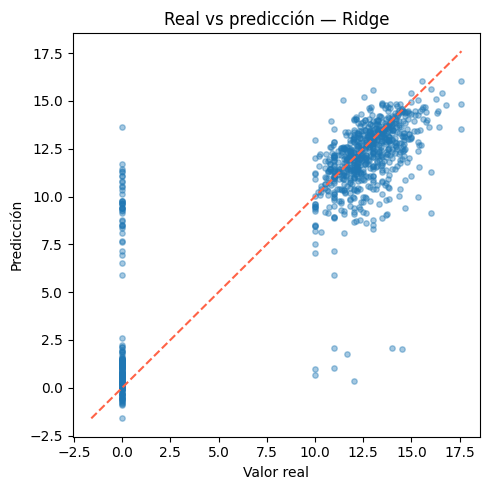

In [28]:
plot_real_vs_pred(y_test, y_pred_ridge, 'Ridge')

## Modelo 2: Lasso      
Lasso usa regularización L1 y, a diferencia de Ridge, puede hacer coeficientes cero. Esto es útil si muchas variables son irrelevantes.

In [29]:
pipe_lasso = Pipeline([('prep', preprocessor),
                       ('reg', Lasso(max_iter=5000))])

# Buscamos alpha con CV
param_lasso = {'reg__alpha': [0.001, 0.1, 1, 10]}

lasso = GridSearchCV(pipe_lasso, param_grid=param_lasso, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
lasso.fit(X_train, y_train)

print("Mejor alpha Lasso: ", lasso.best_params_)
print("Mejor RMSE CV: ", lasso.best_score_)

# Predecimos
y_pred_lasso = lasso.predict(X_test)
evaluar_modelo('Lasso', y_test, y_pred_lasso, resultados_reg)

Mejor alpha Lasso:  {'reg__alpha': 0.001}
Mejor RMSE CV:  -2.6279663671677844
Lasso
MAE:  1.5366701352860688
RMSE:  2.654573101499119
R2:  0.7397217641826344


(1.5366701352860688, np.float64(2.654573101499119), 0.7397217641826344)

In [30]:
# Podemos ver el número de coeficientes que Lasso ha llevado a cero
lasso_coefs = lasso.best_estimator_.named_steps['reg'].coef_
print(f"Coeficientes a cero: {np.sum(lasso_coefs == 0)} de {len(lasso_coefs)}")

Coeficientes a cero: 9 de 75


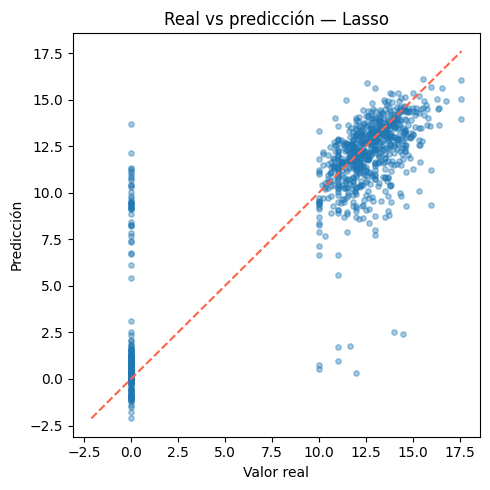

In [31]:
plot_real_vs_pred(y_test, y_pred_lasso, 'Lasso')

## Modelo 3: ElasticNet     
ElasticNet combina las penalizaciones L1 y L2. En este modelo, además del parámetro alpha tenemos l1_ratio que controla el balance entre ambas: l1_ratio = 0 equivale a Ridge puro y l1_ratio = 1 a Lasso puro. Es útil cuando hay variables correlacionadas entre sí.

In [32]:
pipe_enet = Pipeline([('prep', preprocessor),
                       ('reg', ElasticNet(max_iter=5000))])

param_enet = {'reg__alpha': [0.01, 0.1, 1, 10, 100],
              'reg__l1_ratio': [0.2, 0.5, 0.8]}

enet = GridSearchCV(pipe_enet, param_grid=param_enet, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
enet.fit(X_train, y_train)

print("Mejor alpha ElasticNet: ", enet.best_params_)
print("Mejor RMSE CV: ", enet.best_score_)

# Predecimos
y_pred_enet = enet.predict(X_test)
evaluar_modelo('ElasticNet', y_test, y_pred_enet, resultados_reg)

Mejor alpha ElasticNet:  {'reg__alpha': 0.01, 'reg__l1_ratio': 0.5}
Mejor RMSE CV:  -2.614637517857654
ElasticNet
MAE:  1.5057505329703351
RMSE:  2.6461710407198824
R2:  0.7413667840085614


(1.5057505329703351, np.float64(2.6461710407198824), 0.7413667840085614)

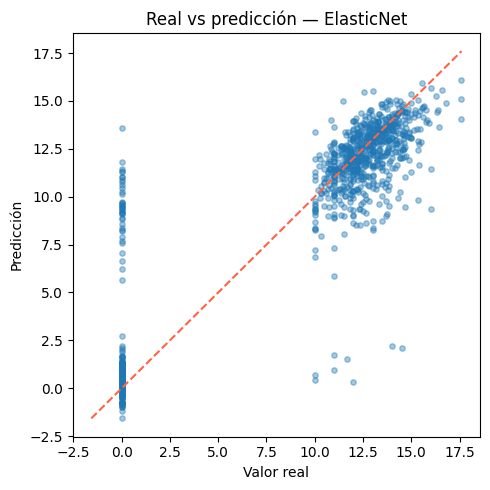

In [33]:
plot_real_vs_pred(y_test, y_pred_enet, 'ElasticNet')

## Modelo 4: RANDOM FOREST REGRESSOR        
Es un modelo no lineal, y al ser un ensemble de árboles, es robusto frente al sobreajuste.

In [34]:
pipe_rf = Pipeline([('prep', preprocessor),
                    ('reg', RandomForestRegressor(random_state=42))])

param_rf = {'reg__n_estimators': [100, 200],
               'reg__max_depth': [None, 10, 20],
               'reg__min_samples_split': [2, 5],
               'reg__min_samples_leaf': [1, 2]}

rf = GridSearchCV(pipe_rf, param_grid=param_rf, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf.fit(X_train, y_train)

print("Mejor alpha Random Forest: ", rf.best_params_)
print("Mejor RMSE CV: ", rf.best_score_)

# Predecimos
y_pred_rf = rf.predict(X_test)
evaluar_modelo('Random Forest', y_test, y_pred_rf, resultados_reg)

Mejor alpha Random Forest:  {'reg__max_depth': 10, 'reg__min_samples_leaf': 2, 'reg__min_samples_split': 5, 'reg__n_estimators': 200}
Mejor RMSE CV:  -2.4625051127199913
Random Forest
MAE:  1.395458621964705
RMSE:  2.6935058239691108
R2:  0.7320311494191747


(1.395458621964705, np.float64(2.6935058239691108), 0.7320311494191747)

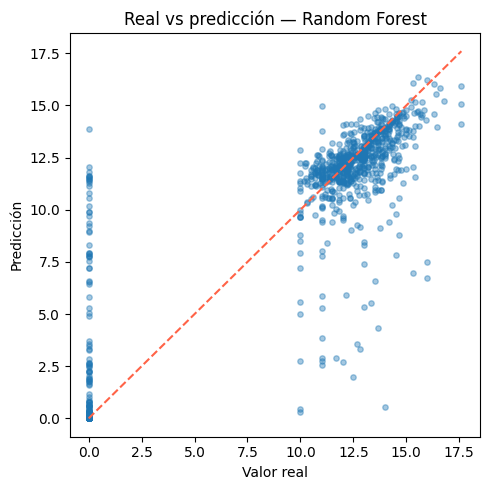

In [35]:
plot_real_vs_pred(y_test, y_pred_rf, 'Random Forest')

## Análisis de residuos del mejor modelo        
Nos quedamos con el modelo con mejor RMSE y analizamos lo residuos para comprobar si el modelo comete errores. Un buen modelo debería tener residuos distribuidos simétricamente alrededor de cero y sin patrones viisbles, así que eso es lo que esperamos ver.

Mejor modelo: ElasticNet


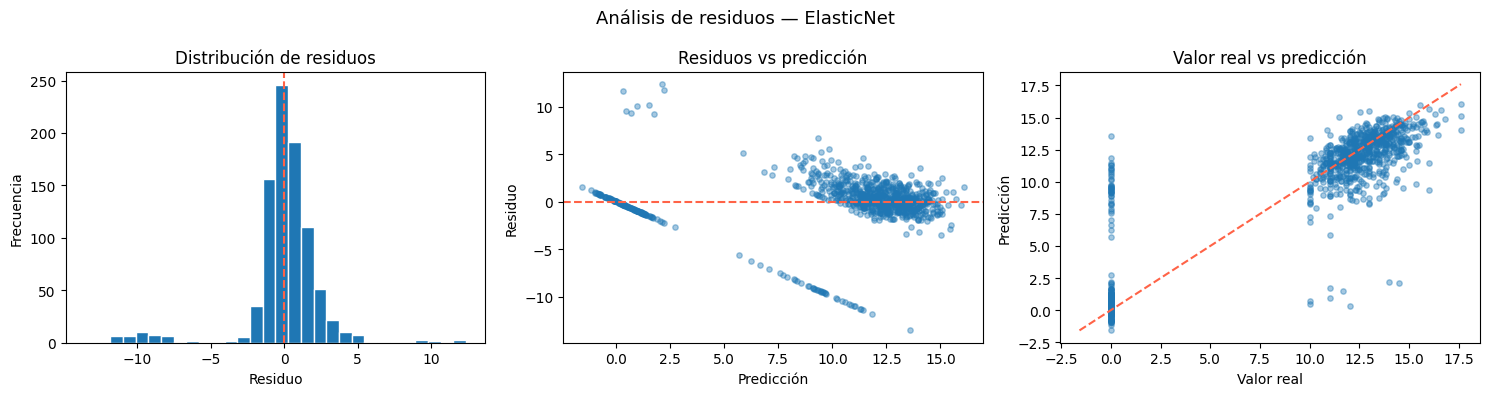

In [36]:
df_res = pd.DataFrame(resultados_reg).sort_values('RMSE')
mejor_nombre = df_res.iloc[0]['Modelo']
print(f'Mejor modelo: {mejor_nombre}')

preds_map = {
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'ElasticNet': y_pred_enet,
    'Random Forest': y_pred_rf
}

plot_residuos(y_test, preds_map[mejor_nombre], mejor_nombre)

## Importancia de variables (Random Forest)     
Como hmos hecho en clasificación, una vez entrenado el modelo de Random Forest, analizamos la importancia de cada variable en la predicción. Esto sirve como pista útil para ver que variables están más asociadas con la nota media del segundo semestre. 

En este caso, esperamos que las variables más relevantes sean claramente las asociadas al rendimiento del primer semestre.

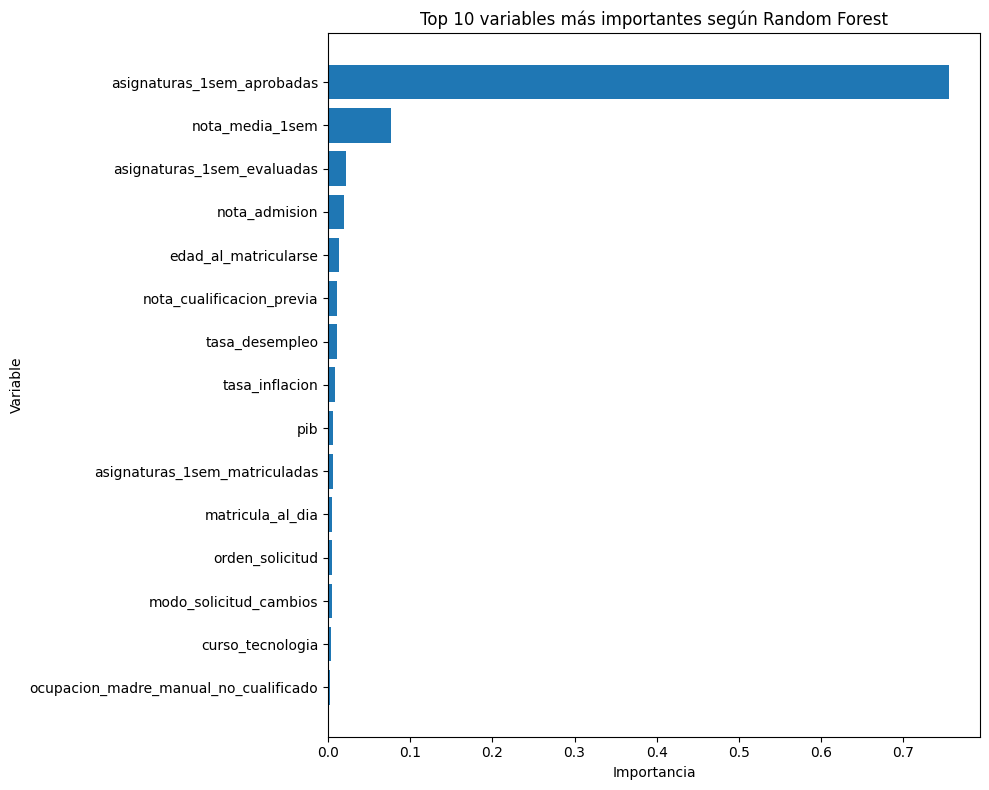

,Variable,Importancia
10,asignaturas_1sem_aprobadas,0.755767
11,nota_media_1sem,0.077210
9,asignaturas_1sem_evaluadas,0.021840
3,nota_admision,0.019981
0,edad_al_matricularse,0.013682
2,nota_cualificacion_previa,0.010825
4,tasa_desempleo,0.010462
5,tasa_inflacion,0.007914
6,pib,0.005870
8,asignaturas_1sem_matriculadas,0.005807


In [ ]:
best_rf = rf.best_estimator_
one_hot = best_rf.named_steps['prep'].named_transformers_['cat']
feature_names = (columnas_numericas + columnas_categoricas_bin + list(one_hot.get_feature_names_out(columnas_categoricas)))

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": best_rf.named_steps['reg'].feature_importances_}).sort_values(by="Importancia", ascending=False)

# Muestro solo con las 15 primeras
top15 = importance_df.head(15).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top15["Variable"], top15["Importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 15 variables más importantes según Random Forest")
plt.tight_layout()
plt.show()

display(importance_df.head(15))

## Comparación final de modelos     
Finalmente, comparamos todos los modelos usando MAE, RMSW y R2. El RMSE penaliza más los errores grandes que el MAE, mientras que R2 indica que proporción de la varianza del target explica el modelo, siendo cuanto más cercano a 1, mejor. 

In [38]:
df_resultados = pd.DataFrame(resultados_reg).sort_values("RMSE")
df_resultados

,Modelo,MAE,RMSE,R2
2,ElasticNet,1.505751,2.646171,0.741367
1,Lasso,1.536670,2.654573,0.739722
0,Ridge,1.516748,2.655323,0.739575
3,Random Forest,1.395459,2.693506,0.732031


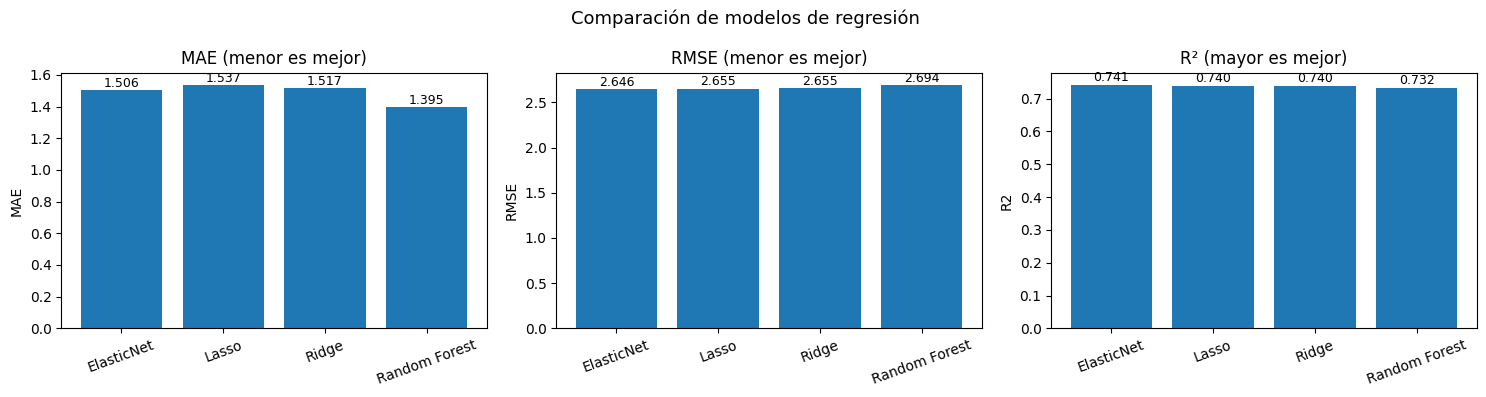

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metrica, titulo in zip(
    axes,
    ['MAE', 'RMSE', 'R2'],
    ['MAE (menor es mejor)', 'RMSE (menor es mejor)', 'R² (mayor es mejor)']
):
    colores = sns.color_palette('muted', len(df_resultados))
    bars = ax.bar(df_resultados['Modelo'], df_resultados[metrica])
    ax.set_title(titulo)
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparación de modelos de regresión', fontsize=13)
plt.tight_layout()
plt.show()

## Conclusiones         
Los modelos obtienen resultados muy similares entre sí, y sorprendentemente, Random Forest no mejora a los modelos lineales en RMSE ni R², lo que 
sugiere que la relación entre las variables y el target es principalmente lineal y la regularización es suficiente.

Además, podemos decir que un R²≈0.74 es razonable dado que no tenemos en cuenta la información del segundo semestre. Las gráficas muestran que todos los modelos tienen dificultades con los estudiantes de nota real 0, que probablemente sean abandonos, que predicen con valores distintos de cero.